# Exp A′ diagnostics — why Multires fails on complex C1 + padded FROG

Follows Karpathy *Recipe* + Google DL Tuning Playbook:
isolate **one scientific factor at a time**, trust the pipeline first, then bias–variance, then ablations **inside** the A′ family.

## Fixed protocol
- **λ = 0** (pulse L1 only; no physics/trace loss)
- Train SNR ~ **U[0, 30] dB** (unchanged)
- **No T sweeps** (T = 53 fs; σ parameters stay T-calibrated / recalibrated only when `N_spikes` changes)
- Primary metric: **high-SNR** reconstruction (30 dB), not noise robustness

## Phases
| Phase | Goal |
|-------|------|
| 0 | Pipeline trust (overfit mini-batch, input-independent, loss@init) |
| 1 | Data / ambiguity / forward consistency |
| 2 | Bias–variance (`n_train`, capacity) |
| 3 | Ablations: FROG padded vs plain, `t*` vs `t0`, `N_spikes` |

Helpers: `exp_a_prime_diagnostics_lib.py`  
Artifacts: `checkpoints/benchmark/exp_a_prime_diagnostics/`


In [30]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np

SRC = Path.cwd()
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import exp_a_prime_diagnostics_lib as diag

OUT = diag.ensure_out_dir()
print("device:", diag.get_device())
print("OUT:", OUT)

# Toggle which blocks to (re)run. Cached JSON/PT skips work unless FORCE=True.
FORCE = False
RUN_PHASE0 = True
RUN_PHASE1 = True
RUN_PHASE2 = True
RUN_PHASE3 = True
NTRAIN_SIZES = [512, 2048, 8192]  # edit freely


device: cuda
OUT: D:\Haim\Haim 3rd paper\Ultra-Fast project\src\checkpoints\benchmark\exp_a_prime_diagnostics


## 0. Pipeline trust


[cache] phase0a: final_train_L1=0.095412
0a overfit near-zero? True final_L1= 0.09541213512420654


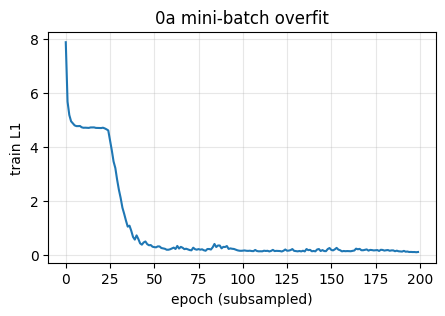

In [31]:
if RUN_PHASE0:
    p0a = diag.phase0a_overfit_minibatch(force=FORCE)
    print("0a overfit near-zero?", p0a.get("ok_near_zero"), "final_L1=", p0a.get("final_train_l1"))
    fig, ax = plt.subplots(figsize=(5, 3))
    ax.plot(p0a["train_losses"])
    ax.set_xlabel("epoch (subsampled)")
    ax.set_ylabel("train L1")
    ax.set_title("0a mini-batch overfit")
    ax.grid(True, alpha=0.3)
    plt.show()
else:
    print("skip phase 0a")


In [32]:
if RUN_PHASE0:
    p0b = diag.phase0b_input_independent(force=FORCE)
    p0c = diag.phase0c_loss_at_init()
    print("0b real better than zero-input?", p0b["real_better"])
    print("0c init L1 vs zero-pred:", p0c)
else:
    print("skip phase 0b/0c")


[cache] phase0b: real=5.5502 zero=5.9413
phase0c: init_L1=7.8044 zero_pred=6.4961
0b real better than zero-input? True
0c init L1 vs zero-pred: {'init_val_l1_mean': 7.804440021514893, 'zero_pred_l1_mean': 6.496097803115845}


## 1. Data stats, ambiguity, forward consistency


In [33]:
if RUN_PHASE1:
    p1a = diag.phase1a_pulse_stats()
    p1b = diag.phase1b_ambiguity_probe()
else:
    print("skip phase 1a/1b")


{
  "n": 512,
  "amp_peak_mean": 0.3297478991744105,
  "support_frac_mean": 0.56121826171875,
  "support_frac_std": 0.07700786579970421,
  "spec_rms_bw_mean": 0.05876912304834075,
  "trace_energy_mean": 22.271442413330078,
  "trace_dynamic_range_db_mean": 12.722429275512695,
  "grid": {
    "n_spikes": 300,
    "t_total_fs": 53.0,
    "coherence_time_fs": 1.3250000000000002,
    "t_center_std_fs": 5.727549044849916
  }
}
phase1b: corr(dI,dE)=0.188  top_collision_score_mean=2.654


## 2. Bias–variance: `n_train` and capacity

If high-SNR error **falls with more data** → data-hungry / variance.  
If it **plateaus** → model bias or information/ambiguity limit.


[cache] phase2_ntrain_512: best_val=5.4072  highSNR_L1=4.4699
[cache] phase2_ntrain_2048: best_val=5.0621  highSNR_L1=4.1218
[cache] phase2_ntrain_8192: best_val=4.8545  highSNR_L1=3.7182
name                                         valL1      hiL1     hiSim    ep
phase2_ntrain_512                           5.4072    4.4699    0.2139    38
phase2_ntrain_2048                          5.0621    4.1218    0.1669    19
phase2_ntrain_8192                          4.8545    3.7182    0.1346    10


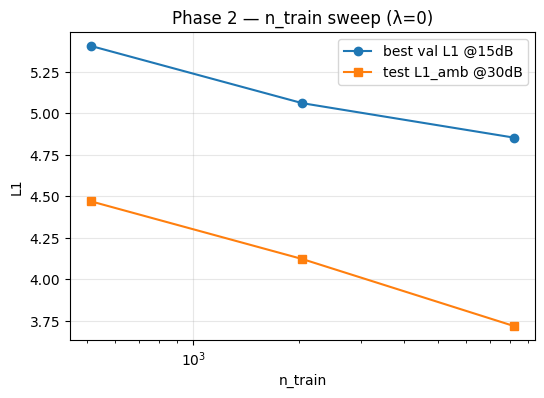

In [34]:
if RUN_PHASE2:
    r_n = diag.run_phase2_ntrain_sweep(NTRAIN_SIZES, force=FORCE)
    print(diag.summarize_results(r_n))
    xs = [r.meta["n_train"] for r in r_n]
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(xs, [r.best_val_l1 for r in r_n], "o-", label="best val L1 @15dB")
    ax.plot(xs, [r.high_snr_l1_amb_mean for r in r_n], "s-", label="test L1_amb @30dB")
    ax.set_xscale("log")
    ax.set_xlabel("n_train")
    ax.set_ylabel("L1")
    ax.set_title("Phase 2 — n_train sweep (λ=0)")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.show()
else:
    print("skip phase 2 n_train")


[cache] phase2_cap_tiny_n2048: best_val=5.1303  highSNR_L1=4.0804
[cache] phase2_cap_default_n2048: best_val=5.1208  highSNR_L1=4.1384
[cache] phase2_cap_wide_n2048: best_val=5.1519  highSNR_L1=4.1079
name                                         valL1      hiL1     hiSim    ep
phase2_cap_tiny_n2048                       5.1303    4.0804    0.1669    22
phase2_cap_default_n2048                    5.1208    4.1384    0.1669    19
phase2_cap_wide_n2048                       5.1519    4.1079    0.1676    19


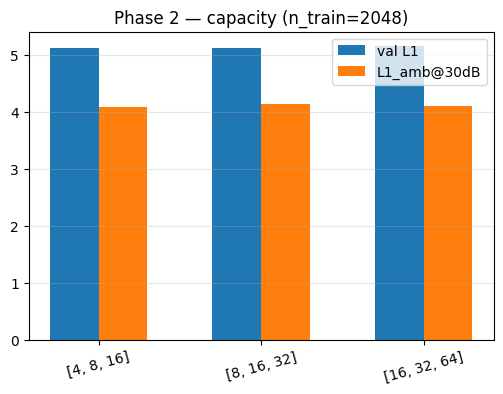

In [35]:
if RUN_PHASE2:
    r_c = diag.run_phase2_capacity_sweep(n_train=2048, force=FORCE)
    print(diag.summarize_results(r_c))
    labels = [r.meta["filters_per_branch"] for r in r_c]
    fig, ax = plt.subplots(figsize=(6, 4))
    x = np.arange(len(r_c))
    ax.bar(x - 0.15, [r.best_val_l1 for r in r_c], width=0.3, label="val L1")
    ax.bar(x + 0.15, [r.high_snr_l1_amb_mean for r in r_c], width=0.3, label="L1_amb@30dB")
    ax.set_xticks(x)
    ax.set_xticklabels([str(l) for l in labels], rotation=15)
    ax.set_title("Phase 2 — capacity (n_train=2048)")
    ax.legend()
    ax.grid(True, alpha=0.3, axis="y")
    plt.show()
else:
    print("skip phase 2 capacity")


In [36]:
# Forward consistency needs a trained 2K checkpoint from phase 2
if RUN_PHASE1:
    p1c = diag.phase1c_forward_consistency(
        train_name="phase2_ntrain_2048", force_train_if_missing=True
    )
    print(
        "Interpretation: high pulse error + low relative trace error → ambiguity; "
        "both high → weak map learning"
    )
else:
    print("skip phase 1c")


{
  "train_name": "phase2_ntrain_2048",
  "snr_db": 30.0,
  "pulse_l1_amb_mean": 4.279968459159136,
  "pulse_l1_amb_std": 0.9123682289717829,
  "trace_l1_mean": 97.88976377248764,
  "trace_l1_std": 12.784303126222415,
  "trace_over_pulse_ratio": 22.871608629331693
}
Interpretation: high pulse error + low relative trace error → ambiguity; both high → weak map learning


## 3. Single-factor ablations (A′ family only)

Each run changes **one** of: FROG mode, canonicalization, `N_spikes` (T fixed).  
`N_spikes` grid: **30 / 100 / 300 / 800** (see next subsection for the dedicated sweep plot).


[cache] phase3_frog_padded_n2048: best_val=5.0533  highSNR_L1=4.1630
[cache] phase3_frog_plain_n2048: best_val=5.2305  highSNR_L1=4.2449
[cache] phase3_canon_tstar_n2048: best_val=5.0660  highSNR_L1=4.0905
[cache] phase3_canon_t0_n2048: best_val=4.7511  highSNR_L1=3.8450
[cache] phase3_spikes_30_n2048: best_val=5.9887  highSNR_L1=5.0057
[cache] phase3_spikes_100_n2048: best_val=5.7327  highSNR_L1=4.4746
[cache] phase3_spikes_300_n2048: best_val=5.0392  highSNR_L1=4.1735
name                                         valL1      hiL1     hiSim    ep
phase3_frog_padded_n2048                    5.0533    4.1630    0.1743    19
phase3_frog_plain_n2048                     5.2305    4.2449    0.1860    23
phase3_canon_tstar_n2048                    5.0660    4.0905    0.1654    19
phase3_canon_t0_n2048                       4.7511    3.8450    0.1435    19
phase3_spikes_30_n2048                      5.9887    5.0057    0.2325    17
phase3_spikes_100_n2048                     5.7327    4.4746   

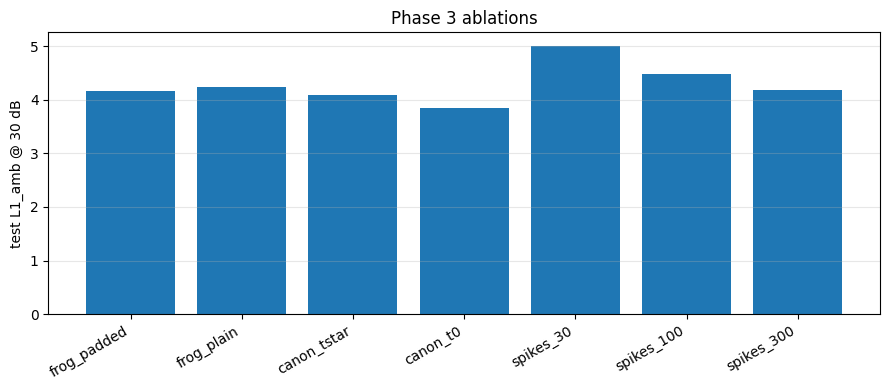

In [37]:
if RUN_PHASE3:
    r3 = diag.run_phase3_ablations(n_train=2048, force=FORCE)
    print(diag.summarize_results(r3))
    names = [r.name.replace("phase3_", "").replace("_n2048", "") for r in r3]
    fig, ax = plt.subplots(figsize=(9, 4))
    x = np.arange(len(r3))
    ax.bar(x, [r.high_snr_l1_amb_mean for r in r3], color="C0")
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=30, ha="right")
    ax.set_ylabel("test L1_amb @ 30 dB")
    ax.set_title("Phase 3 ablations")
    ax.grid(True, alpha=0.3, axis="y")
    plt.tight_layout()
    plt.show()
else:
    print("skip phase 3")


### N_spikes sweep (includes 800)

Same protocol as Phase 3 (`n_train=2048`, λ=0, `t*`, padded FROG).  
`σ_{t,c}` is recalibrated when `N_spikes` changes (T fixed).


[cache] phase3_spikes_30_n2048: best_val=5.9887  highSNR_L1=5.0057
[cache] phase3_spikes_100_n2048: best_val=5.7327  highSNR_L1=4.4746
[cache] phase3_spikes_300_n2048: best_val=5.0392  highSNR_L1=4.1735
[cache] phase3_spikes_800_n2048: best_val=4.9032  highSNR_L1=3.6407
N_spikes sweep (n_train=2048, λ=0):
name                                         valL1      hiL1     hiSim    ep
phase3_spikes_30_n2048                      5.9887    5.0057    0.2325    17
phase3_spikes_100_n2048                     5.7327    4.4746    0.1909    17
phase3_spikes_300_n2048                     5.0392    4.1735    0.1711    19
phase3_spikes_800_n2048                     4.9032    3.6407    0.1342    21


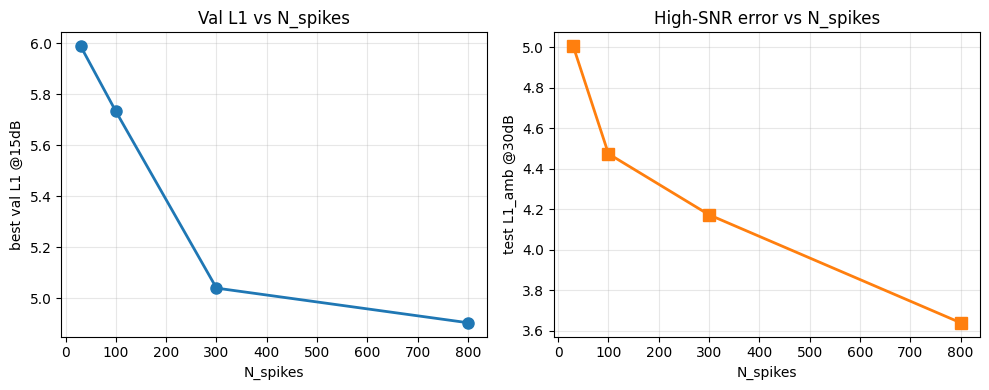

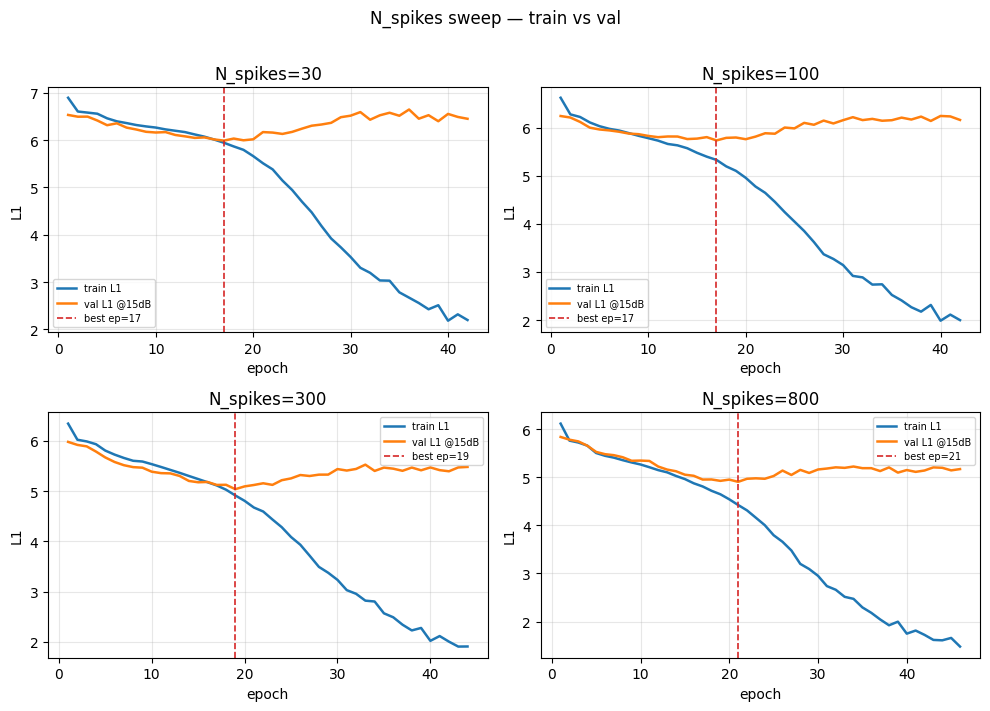

In [38]:
# N_spikes comparison (30 / 100 / 300 / 800) — uses cache; trains if missing
spike_ns = [30, 100, 300, 800]
spike_runs = []
for n_sp in spike_ns:
    name = f"phase3_spikes_{n_sp}_n2048"
    spike_runs.append(
        diag.run_named_train(
            name,
            n_train=2048,
            n_val=200,
            n_test=256,
            n_spikes=n_sp,
            max_epochs=100,
            patience=25,
            force=FORCE,
            verbose=False,
        )
    )

print("N_spikes sweep (n_train=2048, λ=0):")
print(diag.summarize_results(spike_runs))

xs = [r.meta["n_spikes"] for r in spike_runs]
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(xs, [r.best_val_l1 for r in spike_runs], "o-", lw=2, ms=8)
axes[0].set_xlabel("N_spikes")
axes[0].set_ylabel("best val L1 @15dB")
axes[0].set_title("Val L1 vs N_spikes")
axes[0].grid(True, alpha=0.3)

axes[1].plot(xs, [r.high_snr_l1_amb_mean for r in spike_runs], "s-", lw=2, ms=8, color="C1")
axes[1].set_xlabel("N_spikes")
axes[1].set_ylabel("test L1_amb @30dB")
axes[1].set_title("High-SNR error vs N_spikes")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# train / val curves for each N_spikes
fig, axes = plt.subplots(2, 2, figsize=(10, 7), squeeze=False)
for i, r in enumerate(spike_runs):
    ax = axes[i // 2][i % 2]
    tr = np.asarray(r.train_losses, dtype=float)
    va = np.asarray(r.val_l1_pulses, dtype=float)
    ax.plot(np.arange(1, len(tr) + 1), tr, label="train L1", lw=1.8)
    ax.plot(np.arange(1, len(va) + 1), va, label="val L1 @15dB", lw=1.8)
    ax.axvline(int(r.best_epoch), color="C3", ls="--", lw=1.2, label=f"best ep={int(r.best_epoch)}")
    ax.set_title(f"N_spikes={r.meta['n_spikes']}")
    ax.set_xlabel("epoch")
    ax.set_ylabel("L1")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7)
plt.suptitle("N_spikes sweep — train vs val", y=1.01)
plt.tight_layout()
plt.show()


### Recommended params @ `t*` (no `t0`)

Protocol unchanged: `n_train=2048`, λ=0, padded FROG, **`canonicalize=tstar`**.

| param | value |
|-------|-------|
| T | 53 fs |
| N_spikes | 1000 |
| σ_spike | `0.045 * T` ≈ 2.385 fs |
| f_pulse | 0.62 → σ_{t,c} from formula |

Compared below to the default A′ 300-spike and denser 800-spike baselines (same `t*`).


Recommended @ t*: T=53.0, N_spikes=1000, σ_spike=2.3850 fs, f_pulse=0.62
  σ_t,c (meta) = 5.2045 fs
name                                         valL1      hiL1     hiSim    ep
phase3_spikes_300_n2048                     5.0392    4.1735    0.1711    19
phase3_spikes_800_n2048                     4.9032    3.6407    0.1342    21
phase3_rec_spikes1000_sigma045_fpulse062_tstar_n2048    3.6682    2.2466    0.0448    23


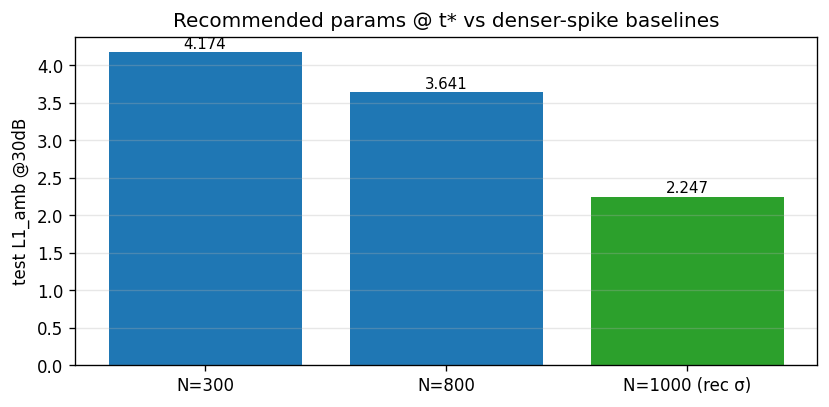

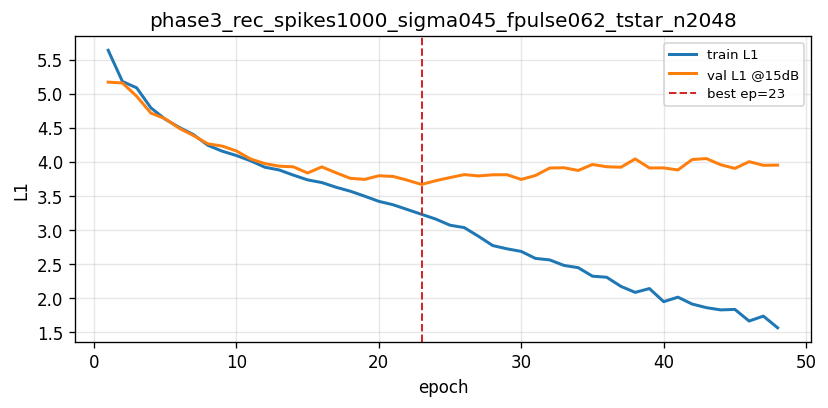

In [1]:
# Recommended pulse params with canonicalize=tstar (NOT t0)
T = 53.0
N_SPIKES = 1000
SIGMA_SPIKE = 0.045 * T
F_PULSE = 0.62
REC_NAME = f"phase3_rec_spikes{N_SPIKES}_sigma045_fpulse062_tstar_n2048"

rec = diag.run_named_train(
    REC_NAME,
    n_train=2048,
    n_spikes=N_SPIKES,
    coherence_time_fs=SIGMA_SPIKE,
    pulse_temporal_fraction=F_PULSE,
    canonicalize_mode="tstar",
    frog_mode="padded",
    force=FORCE,
    verbose=False,
)

baselines = []
for n_sp in (300, 800):
    baselines.append(
        diag.run_named_train(
            f"phase3_spikes_{n_sp}_n2048",
            n_train=2048,
            n_spikes=n_sp,
            force=False,
            verbose=False,
        )
    )

print(
    f"Recommended @ t*: T={T}, N_spikes={N_SPIKES}, "
    f"σ_spike={SIGMA_SPIKE:.4f} fs, f_pulse={F_PULSE}"
)
print(f"  σ_t,c (meta) = {rec.meta['t_center_std_fs']:.4f} fs")
print(diag.summarize_results([*baselines, rec]))

# bar compare hiSNR L1
labels = [f"N={r.meta['n_spikes']}" + (" (rec σ)" if r.name == REC_NAME else "") for r in [*baselines, rec]]
vals = [r.high_snr_l1_amb_mean for r in [*baselines, rec]]
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(labels, vals, color=["C0", "C0", "C2"])
ax.set_ylabel("test L1_amb @30dB")
ax.set_title("Recommended params @ t* vs denser-spike baselines")
ax.grid(True, axis="y", alpha=0.3)
for i, v in enumerate(vals):
    ax.text(i, v + 0.05, f"{v:.3f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

# train / val curve
tr = np.asarray(rec.train_losses, dtype=float)
va = np.asarray(rec.val_l1_pulses, dtype=float)
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(np.arange(1, len(tr) + 1), tr, label="train L1", lw=1.8)
ax.plot(np.arange(1, len(va) + 1), va, label="val L1 @15dB", lw=1.8)
ax.axvline(rec.best_epoch, color="C3", ls="--", lw=1.2, label=f"best ep={rec.best_epoch}")
ax.set_xlabel("epoch")
ax.set_ylabel("L1")
ax.set_title(REC_NAME)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## Summary table


In [39]:
rows = []
for p in sorted(OUT.glob("phase*.json")):
    if p.name.startswith("phase0") or p.name.startswith("phase1"):
        continue
    d = json.loads(p.read_text(encoding="utf-8"))
    if "high_snr_l1_amb_mean" not in d:
        continue
    rows.append(
        (
            p.stem,
            d.get("best_val_l1"),
            d.get("high_snr_l1_amb_mean"),
            d.get("high_snr_sim_amb_mean"),
            d.get("best_epoch"),
        )
    )

hdr = f"{'run':42s} {'valL1':>8s} {'hiL1':>8s} {'hiSim':>8s} {'ep':>4s}"
print(hdr)
for r in rows:
    print(f"{r[0]:42s} {r[1]:8.4f} {r[2]:8.4f} {r[3]:8.4f} {r[4]:4d}")

print("\nArtifacts in", OUT)


run                                           valL1     hiL1    hiSim   ep
phase2_cap_default_n2048                     5.1208   4.1384   0.1669   19
phase2_cap_tiny_n2048                        5.1303   4.0804   0.1669   22
phase2_cap_wide_n2048                        5.1519   4.1079   0.1676   19
phase2_ntrain_2048                           5.0621   4.1218   0.1669   19
phase2_ntrain_512                            5.4072   4.4699   0.2139   38
phase2_ntrain_8192                           4.8545   3.7182   0.1346   10
phase3_canon_t0_n2048                        4.7511   3.8450   0.1435   19
phase3_canon_tstar_n2048                     5.0660   4.0905   0.1654   19
phase3_frog_padded_n2048                     5.0533   4.1630   0.1743   19
phase3_frog_plain_n2048                      5.2305   4.2449   0.1860   23
phase3_spikes_100_n2048                      5.7327   4.4746   0.1909   17
phase3_spikes_300_n2048                      5.0392   4.1735   0.1711   19
phase3_spikes_30_n2048   

## Training / validation curves

Load cached JSON runs and plot **train L1** vs **val L1 @ 15 dB** (checkpoint chosen at best val).
Vertical dashed line = `best_epoch`.


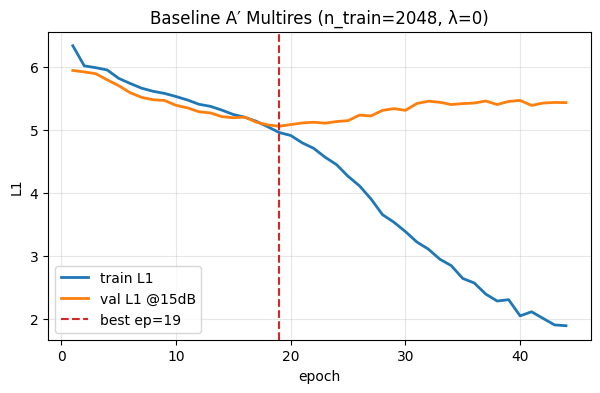

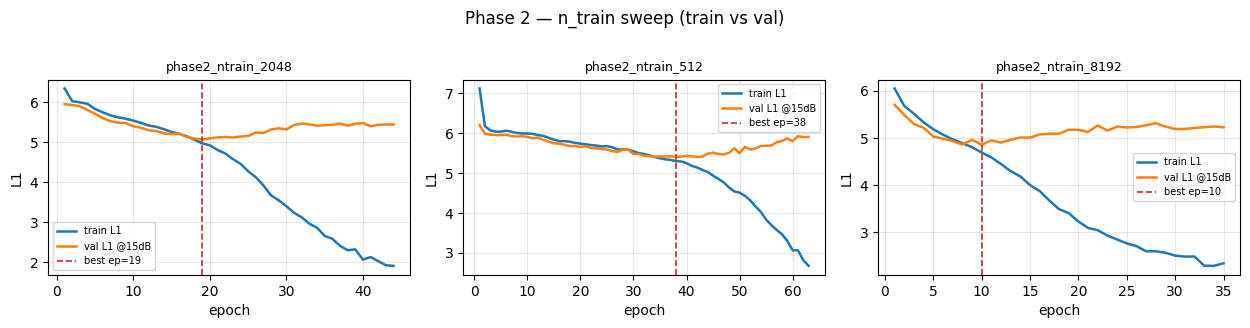

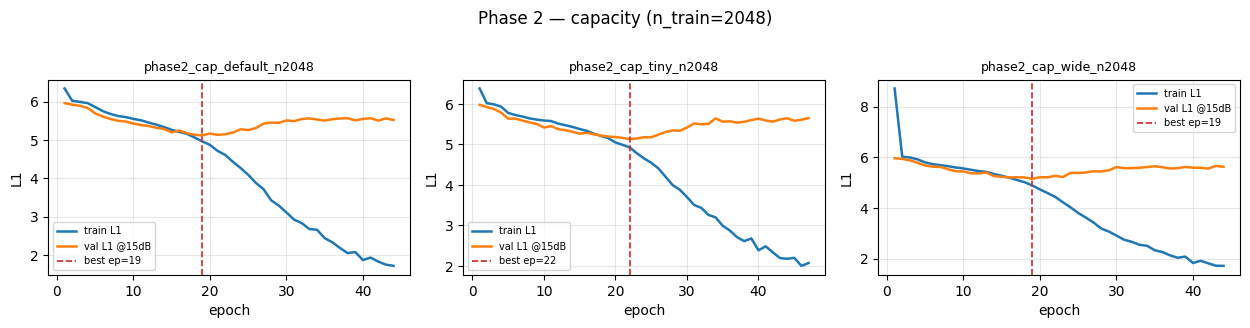

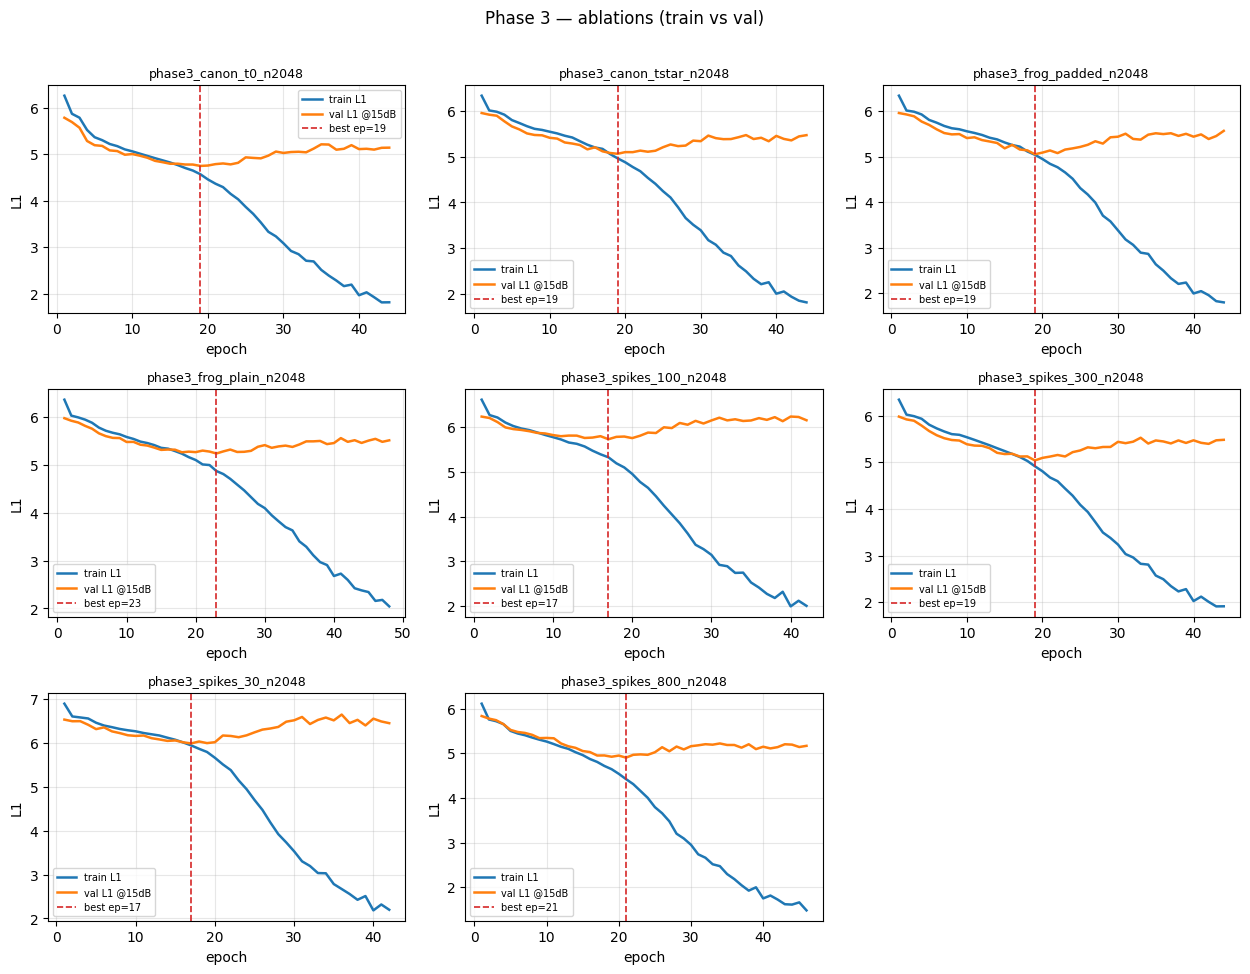

In [40]:
def load_curve_runs(patterns):
    """Load diagnostic JSONs that contain train/val curves."""
    runs = []
    for pat in patterns:
        for p in sorted(OUT.glob(pat)):
            d = json.loads(p.read_text(encoding="utf-8"))
            if "train_losses" not in d or "val_l1_pulses" not in d:
                continue
            runs.append(d)
    return runs


def plot_train_val_curves(runs, title, ncols=3):
    if not runs:
        print(f"No curve artifacts for: {title}")
        return
    n = len(runs)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.2 * nrows), squeeze=False)
    for i, d in enumerate(runs):
        ax = axes[i // ncols][i % ncols]
        tr = np.asarray(d["train_losses"], dtype=float)
        va = np.asarray(d["val_l1_pulses"], dtype=float)
        ep_tr = np.arange(1, len(tr) + 1)
        ep_va = np.arange(1, len(va) + 1)
        ax.plot(ep_tr, tr, label="train L1", lw=1.8)
        ax.plot(ep_va, va, label="val L1 @15dB", lw=1.8)
        be = int(d.get("best_epoch", 0) or 0)
        if be > 0:
            ax.axvline(be, color="C3", ls="--", lw=1.2, label=f"best ep={be}")
        name = d.get("name", "run")
        ax.set_title(name, fontsize=9)
        ax.set_xlabel("epoch")
        ax.set_ylabel("L1")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=7)
    for j in range(n, nrows * ncols):
        axes[j // ncols][j % ncols].axis("off")
    fig.suptitle(title, y=1.01)
    plt.tight_layout()
    plt.show()


# --- Main baseline (closest to Exp A′ 2K, λ=0) ---
_base = OUT / "phase2_ntrain_2048.json"
if _base.exists():
    d = json.loads(_base.read_text(encoding="utf-8"))
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(np.arange(1, len(d["train_losses"]) + 1), d["train_losses"], label="train L1", lw=2)
    ax.plot(np.arange(1, len(d["val_l1_pulses"]) + 1), d["val_l1_pulses"], label="val L1 @15dB", lw=2)
    ax.axvline(int(d["best_epoch"]), color="C3", ls="--", label=f"best ep={int(d['best_epoch'])}")
    ax.set_xlabel("epoch")
    ax.set_ylabel("L1")
    ax.set_title("Baseline A′ Multires (n_train=2048, λ=0)")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.show()
else:
    print("missing", _base)

# --- Phase 2: n_train sweep ---
plot_train_val_curves(
    load_curve_runs(["phase2_ntrain_*.json"]),
    "Phase 2 — n_train sweep (train vs val)",
)

# --- Phase 2: capacity ---
plot_train_val_curves(
    load_curve_runs(["phase2_cap_*_n2048.json"]),
    "Phase 2 — capacity (n_train=2048)",
)

# --- Phase 3: ablations ---
plot_train_val_curves(
    load_curve_runs(["phase3_*.json"]),
    "Phase 3 — ablations (train vs val)",
    ncols=3,
)


## How to read outcomes (next actions)

| Finding | Likely cause | Next fix direction |
|---------|--------------|--------------------|
| 0a cannot overfit | pipeline / loss / packing bug | fix before anything else |
| 0b zero ≈ real | label leak or dead input path | fix data wiring |
| more `n_train` helps a lot | variance / under-data | scale data (+ capacity) |
| capacity helps, data less | architectural bias | wider Multires / other arch |
| plain FROG ≪ padded error | spectral padding / crop issue | revisit FROGNetPadded settings |
| `t0` ≪ `t*` | peak canonicalization hurts regression | switch / rethink gauge |
| more spikes (→800) **improves** high-SNR error | denser SASE / recalibrated σ_t,c easier or more informative for Multires | keep exploring spike density; not “simpler pulses only” |
| FROG(Ê) good, Ê bad | inverse ambiguity | ambiguity-aware loss / constraints (later; still λ=0 here) |


## Updated C1 Multires 2K — SNR sweep + learning curves

Protocol matches the **current** free parameters in `stochastic_pulses_generator_NB.ipynb`
(code cell), with TRACE spectral resolution from the same κ / `N_FFT` pipeline.

| param | value |
|-------|-------|
| T | 53.0 fs |
| N_spikes | 400 |
| σ_spike | 1.3250 fs |
| f_pulse | 0.34 |
| σ_t,c | 3.0646 fs |
| κ (`FRACTION_FROM_NYQUIST`) | 0.52 |
| N_FFT | 88 |
| ΔE_actual | 0.055863 eV |
| canonicalize | `tstar` |
| n_train | 2048 (Multires 2K) |
| λ | 0 (pulse L1 only) |
| train SNR | U[0.0, 30.0] dB |
| val SNR | 15.0 dB |

Artifacts: `updated_c1_nb_multires_2k_lam0.json`, `updated_c1_nb_multires_2k_lam0.pt`, `updated_c1_nb_multires_2k_lam0_snr_sweep.npz` under `checkpoints/benchmark/exp_a_prime_diagnostics/`.


Multires 2K (λ=0) — updated C1 from stochastic_pulses_generator_NB
  T=53.0  N_spikes=400  σ_spike=1.3250  f_pulse=0.34
  σ_t,c=3.0646  κ=0.52  N_FFT=88  dE=0.055863 eV  canon=tstar
  n_train=2048  train SNR U[0.0, 30.0]  val@15.0dB
  best_val_L1=3.0385  best_epoch=26  stopped=51  wall=136.2s

SNR sweep L1_amb (mean):
  SNR=-10.0 dB  L1_amb=2.8662±0.8071  Sim_amb=0.1281
  SNR= -5.0 dB  L1_amb=2.2848±0.7169  Sim_amb=0.0803
  SNR=  0.0 dB  L1_amb=2.1196±0.7126  Sim_amb=0.0688
  SNR=  5.0 dB  L1_amb=2.0885±0.7078  Sim_amb=0.0649
  SNR= 10.0 dB  L1_amb=2.0629±0.6876  Sim_amb=0.0629
  SNR= 15.0 dB  L1_amb=2.0505±0.6852  Sim_amb=0.0620
  SNR= 20.0 dB  L1_amb=2.0513±0.6877  Sim_amb=0.0616
  SNR= 25.0 dB  L1_amb=2.0515±0.6902  Sim_amb=0.0619
  SNR= 30.0 dB  L1_amb=2.0499±0.6883  Sim_amb=0.0616


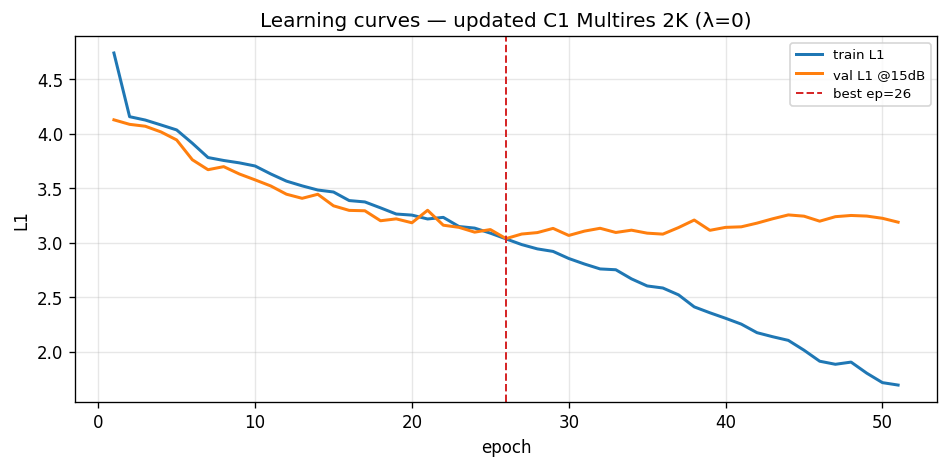

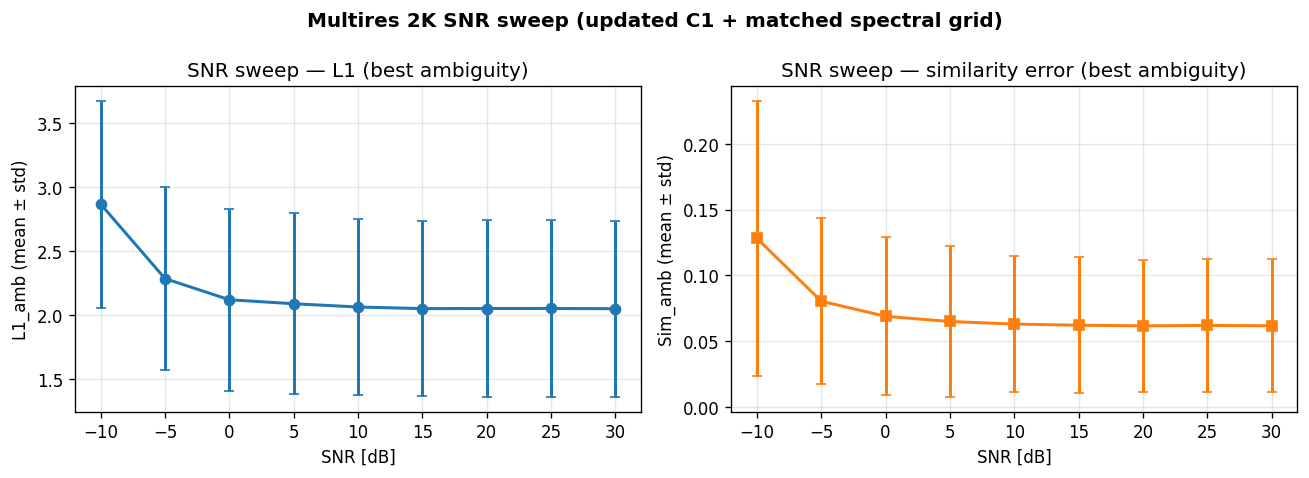

In [1]:
# Updated C1 (current stochastic NB params) — Multires 2K λ=0: curves + SNR sweep
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

_NAME = "updated_c1_nb_multires_2k_lam0"
_OUT = Path("checkpoints/benchmark/exp_a_prime_diagnostics")
_json = json.loads((_OUT / f"{_NAME}.json").read_text(encoding="utf-8"))
_z = np.load(_OUT / f"{_NAME}_snr_sweep.npz")
_m = _json["meta"]

print("Updated C1 Multires 2K (λ=0)")
print(
    f"  T={_m['t_total_fs']}  N_spikes={_m['n_spikes']}  "
    f"σ_spike={_m['coherence_time_fs']:.4f}  f_pulse={_m['pulse_temporal_fraction']}  "
    f"κ={_m['fraction_from_nyquist']}  N_FFT={_m['n_fft']}"
)
print(
    f"  best_val_L1={_json['best_val_l1']:.4f}  best_epoch={_json['best_epoch']}  "
    f"stopped={_json['stopped_epoch']}"
)
print("\nSNR sweep (L1_amb):")
for s, m, sd in zip(_z["snr_sweep_db"], _z["cnn_l1_amb_m"], _z["cnn_l1_amb_s"]):
    print(f"  SNR={s:5.1f} dB  L1_amb={m:.4f}±{sd:.4f}")

# Learning curves
_tr = np.asarray(_json["train_losses"], dtype=float)
_va = np.asarray(_json["val_l1_pulses"], dtype=float)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.arange(1, len(_tr) + 1), _tr, lw=1.8, label="train L1")
ax.plot(np.arange(1, len(_va) + 1), _va, lw=1.8, label="val L1 @15dB")
ax.axvline(_json["best_epoch"], color="C3", ls="--", lw=1.2, label=f"best ep={_json['best_epoch']}")
ax.set_xlabel("epoch")
ax.set_ylabel("L1")
ax.set_title("Learning curves — updated C1 Multires 2K (λ=0)")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# SNR sweep
_snr = _z["snr_sweep_db"]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].errorbar(_snr, _z["cnn_l1_amb_m"], yerr=_z["cnn_l1_amb_s"], fmt="o-", lw=1.8, ms=6, capsize=3)
axes[0].set_xlabel("SNR [dB]")
axes[0].set_ylabel("L1_amb")
axes[0].set_title("SNR sweep — L1 (best ambiguity)")
axes[0].grid(True, alpha=0.3)

axes[1].errorbar(
    _snr, _z["cnn_sim_amb_m"], yerr=_z["cnn_sim_amb_s"],
    fmt="s-", lw=1.8, ms=6, capsize=3, color="C1",
)
axes[1].set_xlabel("SNR [dB]")
axes[1].set_ylabel("Sim_amb")
axes[1].set_title("SNR sweep — similarity error (best ambiguity)")
axes[1].grid(True, alpha=0.3)
fig.suptitle("Multires 2K SNR sweep (updated C1 + matched spectral grid)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


## Updated C1 Multires 2K — **physics** (trace λ-search)

Same pulse + spectral protocol as the λ=0 chapter, but with **physics/trace loss** and λ grid search.

| param | value |
|-------|-------|
| T / N_spikes / σ_spike | 53.0 / 400 / 1.3250 fs |
| f_pulse / κ / N_FFT | 0.34 / 0.52 / 88 |
| λ grid | [0, 0.75, 1.5, 2.25, 3] |
| **λ\*** | **0.0000** (best val L1 = 2.9846) |
| n_train | 2048 · train SNR U[0,30] · val @15 dB · canon=`t*` |

**Finding:** on this updated C1 setup, **λ\*=0** (no trace loss) wins the val-L1 grid — physics weight did not improve validation pulse L1.


Multires 2K PHYSICS (trace λ-search) — updated C1 from stochastic NB
  T=53.0  N_spikes=400  σ_spike=1.3250  f_pulse=0.34  κ=0.52  N_FFT=88
  λ* = 0.0000  best_val_L1 = 2.9846  (baseline λ=0 val=2.9846)

λ grid (val L1 @15dB):
  λ=0.00  valL1=2.9846  best_ep=24  <-- λ*
  λ=0.75  valL1=3.0239  best_ep=68
  λ=1.50  valL1=3.1746  best_ep=74
  λ=2.25  valL1=3.0851  best_ep=149
  λ=3.00  valL1=3.1457  best_ep=176

SNR sweep L1_amb @ λ* vs λ=0:
  SNR=-10.0 dB  λ*: 2.8490  |  λ=0: 2.8927
  SNR= -5.0 dB  λ*: 2.3577  |  λ=0: 2.3420
  SNR=  0.0 dB  λ*: 2.0840  |  λ=0: 2.1049
  SNR=  5.0 dB  λ*: 2.0590  |  λ=0: 2.0490
  SNR= 10.0 dB  λ*: 2.0288  |  λ=0: 2.0427
  SNR= 15.0 dB  λ*: 2.0401  |  λ=0: 2.0320
  SNR= 20.0 dB  λ*: 2.0424  |  λ=0: 2.0398
  SNR= 25.0 dB  λ*: 2.0411  |  λ=0: 2.0426
  SNR= 30.0 dB  λ*: 2.0413  |  λ=0: 2.0433


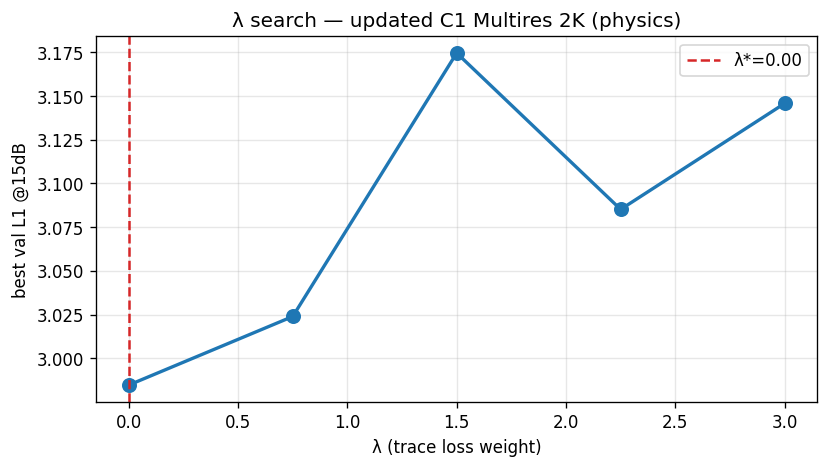

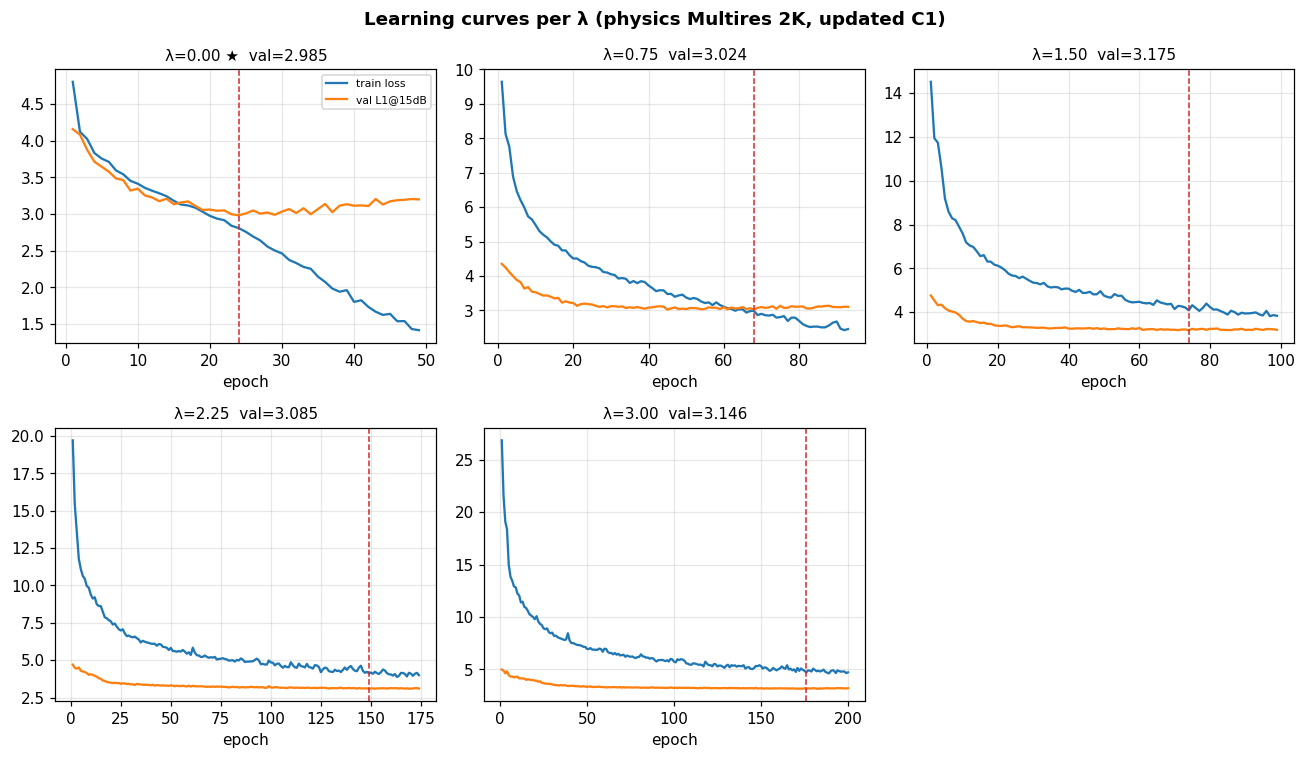

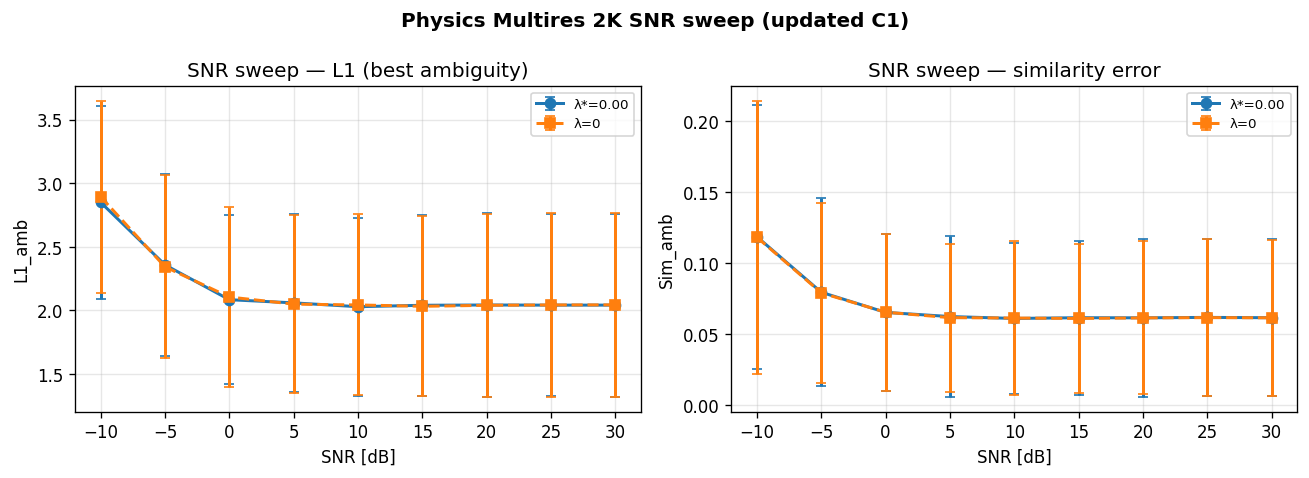

In [1]:
# Physics Multires 2K (λ-search) — updated C1: curves + SNR sweep
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

_TAG = "updated_c1_nb_multires_2k_physics"
_OUT = Path("checkpoints/benchmark/exp_a_prime_diagnostics")
_npz = np.load(_OUT / f"{_TAG}.npz")
_meta = json.loads((_OUT / f"{_TAG}_meta.json").read_text(encoding="utf-8"))
_opt = np.load(_OUT / f"{_TAG}_opt_snr_sweep.npz")
_base = np.load(_OUT / f"{_TAG}_baseline_snr_sweep.npz")
_runs = {float(r["lam"]): r for r in _meta["runs"]}
_lam_opt = float(_npz["lambda_opt"])

print(f"λ* = {_lam_opt:.4f}  best_val = {float(_npz['best_val_at_opt']):.4f}")
print("λ grid:")
for lam, bv, be in zip(_npz["lambda_grid"], _npz["best_val_l1"], _npz["best_epochs"]):
    mark = " <-- λ*" if abs(float(lam) - _lam_opt) < 1e-9 else ""
    print(f"  λ={float(lam):.2f}  valL1={float(bv):.4f}  ep={int(be)}{mark}")

# λ vs val
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(_npz["lambda_grid"], _npz["best_val_l1"], "o-", lw=2, ms=8)
ax.axvline(_lam_opt, color="C3", ls="--", label=f"λ*={_lam_opt:.2f}")
ax.set_xlabel("λ")
ax.set_ylabel("best val L1 @15dB")
ax.set_title("λ search — physics Multires 2K (updated C1)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# Learning curves
fig, axes = plt.subplots(2, 3, figsize=(12, 7), squeeze=False)
for i, lam in enumerate(sorted(_runs.keys())):
    ax = axes[i // 3][i % 3]
    r = _runs[lam]
    tr = np.asarray(r["train_losses"], float)
    va = np.asarray(r["val_l1_pulses"], float)
    ax.plot(np.arange(1, len(tr) + 1), tr, lw=1.5, label="train loss")
    ax.plot(np.arange(1, len(va) + 1), va, lw=1.5, label="val L1@15dB")
    ax.axvline(r["best_epoch"], color="C3", ls="--", lw=1.0)
    star = " ★" if abs(lam - _lam_opt) < 1e-9 else ""
    ax.set_title(f"λ={lam:.2f}{star}  val={r['best_val_l1']:.3f}", fontsize=10)
    ax.grid(True, alpha=0.3)
    if i == 0:
        ax.legend(fontsize=7)
for j in range(len(_runs), 6):
    axes[j // 3][j % 3].axis("off")
fig.suptitle("Learning curves per λ", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

# SNR sweep
snr = _opt["snr_sweep_db"]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].errorbar(snr, _opt["cnn_l1_amb_m"], yerr=_opt["cnn_l1_amb_s"], fmt="o-", lw=1.8, ms=6, capsize=3, label=f"λ*={_lam_opt:.2f}")
axes[0].errorbar(snr, _base["cnn_l1_amb_m"], yerr=_base["cnn_l1_amb_s"], fmt="s--", lw=1.8, ms=6, capsize=3, label="λ=0")
axes[0].set_xlabel("SNR [dB]"); axes[0].set_ylabel("L1_amb"); axes[0].set_title("SNR sweep — L1")
axes[0].grid(True, alpha=0.3); axes[0].legend(fontsize=8)
axes[1].errorbar(snr, _opt["cnn_sim_amb_m"], yerr=_opt["cnn_sim_amb_s"], fmt="o-", lw=1.8, ms=6, capsize=3, label=f"λ*={_lam_opt:.2f}")
axes[1].errorbar(snr, _base["cnn_sim_amb_m"], yerr=_base["cnn_sim_amb_s"], fmt="s--", lw=1.8, ms=6, capsize=3, label="λ=0")
axes[1].set_xlabel("SNR [dB]"); axes[1].set_ylabel("Sim_amb"); axes[1].set_title("SNR sweep — Sim")
axes[1].grid(True, alpha=0.3); axes[1].legend(fontsize=8)
fig.suptitle("Physics Multires 2K SNR sweep (updated C1)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


## Sanity: Exp A pulses × new-pipeline ablation

**Question:** Why does Multires-2K look much worse on “updated C1” (~val L1 ≈ 3.0) than on Experiment A (~2.53), even when pulse difficulty was intended to be similar?

**Design:** Keep **Exp A pulse parameters** (`StochasticPulseConfig`: T=100 fs, N_spikes=30, σ_spike=2.5, σ_tc=5.73) and Multires-2K train hyperparams identical. Factor the new pipeline into a 2×2:

| variant | FROG | canonicalize |
|---------|------|--------------|
| `plain_t0` | plain `FROGNet` | `t0` (Exp A control) |
| `plain_tstar` | plain `FROGNet` | `t*` |
| `padded_t0` | `FROGNetPadded` (κ=0.52 → N_FFT=88) | `t0` |
| `padded_tstar` | padded | `t*` (full new pipeline) |

Script: `scripts/run_exp_a_pipeline_ablation.py`  
Artifacts: `checkpoints/benchmark/exp_a_prime_diagnostics/exp_a_ablation_*` + `exp_a_pipeline_ablation_summary.json`

### Results (best val L1 @ 15 dB)

| | λ* | val* | λ=0 |
|--|----|------|-----|
| Exp A cached (original) | 1.5 | **2.53** | 2.64 |
| plain_t0 (replay) | 0.75 | **2.56** | 2.63 |
| padded_t0 | 0.75 | **2.47** | 2.54 |
| plain_tstar | 0.0 | **3.09** | 3.09 |
| padded_tstar (full new) | 0.0 | **3.00** | 3.00 |

### Verdict

- **Control replay works** — Exp A pulses + plain FROG + `t0` still land near ~2.56 (λ* jitter 0.75 vs 1.5 is within grid noise).
- **Padded FROG is not the problem** — with `t0` it is as good or slightly better (~2.47).
- **`canonicalize_field_tstar` is the main regression** — alone it moves Exp A Multires into the ~3.0 regime; padded+`t*` matches updated-C1 physics (~3.0, λ*=0).
- Therefore the gap vs Exp A is **not** primarily “harder updated C1 pulse params”; it is the **new ambiguity removal (`t*`)** used in the C1 reconstruction pipeline.


Exp A cached: λ*=1.50 val*=2.5332

plain_t0        λ*=0.75  val*=2.5578  λ0=2.6251  | Exp A control: plain FROGNet + t0
padded_tstar    λ*=0.00  val*=3.0023  λ0=3.0023  | full new pipeline: padded FROG + t*
plain_tstar     λ*=0.00  val*=3.0897  λ0=3.0897  | t* only (plain FROG)
padded_t0       λ*=0.75  val*=2.4654  λ0=2.5370  | padded FROG only (t0)


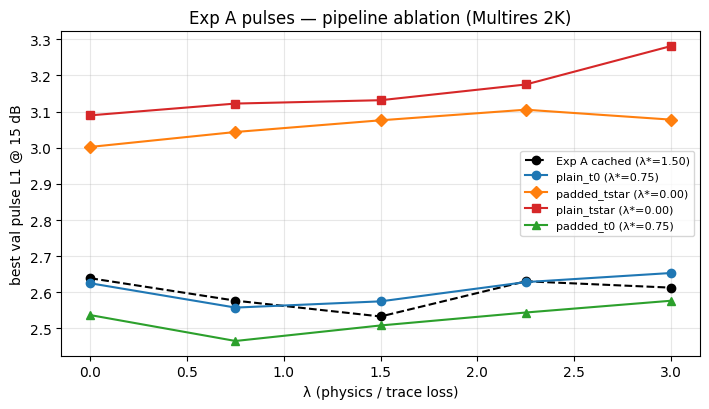

In [1]:
# Exp A pulses × pipeline ablation — load summary + λ curves
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

OUT = Path("checkpoints/benchmark/exp_a_prime_diagnostics")
summary = json.loads((OUT / "exp_a_pipeline_ablation_summary.json").read_text(encoding="utf-8"))
ref = summary["exp_a_reference"]
print("Exp A cached:", f"λ*={ref['lambda_opt']:.2f}", f"val*={ref['best_val_at_opt']:.4f}")
print()
rows = []
for v in summary["variants"]:
    print(
        f"{v['variant']:14s}  λ*={v['lambda_opt']:.2f}  "
        f"val*={v['best_val_at_opt']:.4f}  λ0={v['best_val_at_baseline']:.4f}  | {v['note']}"
    )
    rows.append(v)

lam_grid = np.linspace(0.0, 3.0, 5)
fig, ax = plt.subplots(figsize=(7.2, 4.2))
ax.plot(lam_grid, ref["best_val_l1"], "k--o", label=f"Exp A cached (λ*={ref['lambda_opt']:.2f})")
styles = {
    "plain_t0": ("C0", "-o"),
    "plain_tstar": ("C3", "-s"),
    "padded_t0": ("C2", "-^"),
    "padded_tstar": ("C1", "-D"),
}
for v in rows:
    sty = styles.get(v["variant"], ("gray", "-o"))
    ax.plot(
        lam_grid,
        v["best_val_l1"],
        sty[1],
        color=sty[0],
        label=f"{v['variant']} (λ*={v['lambda_opt']:.2f})",
    )
ax.set_xlabel("λ (physics / trace loss)")
ax.set_ylabel("best val pulse L1 @ 15 dB")
ax.set_title("Exp A pulses — pipeline ablation (Multires 2K)")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
